# South Africa 2023 Dispatch Validation - Clean Module 14c Scenarios

This standalone notebook compares observed Eskom calendar-year 2023 dispatch with three updated fixed-fleet PyPSA-Earth networks. The purpose is to inspect hourly and monthly dispatch behaviour after the clean coal 48.5% EAF input path, the nuclear 50% availability setting, optional VRE scaling, and the optional annual OCGT cap.

Only four comparison cases are used throughout:

| Case | Meaning |
|---|---|
| Eskom CY2023 | Observed Eskom reference data, with the model demand boundary adjusted for imports, exports, Other RE, and the unattributed dispatchable residual. |
| No VRE / no OCGT cap | Clean coal+nuclear availability network without VRE scaling and without the annual OCGT energy cap. |
| VRE only | Same network with the wind/solar/CSP scaling layer enabled, without the annual OCGT energy cap. |
| VRE + OCGT cap | Same network with VRE scaling and the annual OCGT energy cap enabled. |

The notebook is designed to be read outside the project: EAF means equivalent availability factor, VRE means variable renewable energy, OCGT means open-cycle gas turbine generation, and load shedding is represented with Eskom's MLR + ILS + IOS observed curtailment proxy.

In [1]:
import logging
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
logging.getLogger("pypsa").setLevel(logging.ERROR)

try:
    import pypsa
except ImportError as exc:
    raise ImportError(
        "This notebook requires the pypsa-earth Python environment. "
        "Run it from the repository root with the pypsa-earth conda environment."
    ) from exc


def find_repo_root(start=None):
    current = Path.cwd() if start is None else Path(start).resolve()
    for path in [current, *current.parents]:
        if (path / "Snakefile").exists() and (path / "data").exists():
            return path
    raise FileNotFoundError("Could not find the pypsa-earth repository root.")


ROOT = find_repo_root()
DATA_DIR = ROOT / "data" / "za_validation"
NETWORK_DIR = ROOT / "results" / "za_2023_fixed_validation" / "networks"
ESKOM_HOURLY_PATH = DATA_DIR / "eskom_2023_hourly_clean.csv"
ESKOM_TARGET_PATH = DATA_DIR / "eskom_2023_targets_by_carrier.csv"

SCENARIOS = {
    "no_vre_no_cap": {
        "label": "No VRE / no OCGT cap",
        "short": "No VRE",
        "suffix": "EAF-CONFIG-coal485_nuclear50_no_vre_no_ocgt_cap",
        "color": "#4C78A8",
        "notes": "Clean coal 48.5% EAF and nuclear 50%, without VRE scaling and without the annual OCGT energy cap.",
    },
    "vre_only": {
        "label": "VRE only",
        "short": "VRE",
        "suffix": "EAF-CONFIG-coal485_nuclear50_vre_only",
        "color": "#F58518",
        "notes": "Adds the wind/solar/CSP scaling layer while leaving OCGT uncapped.",
    },
    "vre_cap": {
        "label": "VRE + OCGT cap",
        "short": "VRE + cap",
        "suffix": "EAF-CONFIG-coal485_nuclear50_vre_ocgt_cap",
        "color": "#54A24B",
        "notes": "Adds VRE scaling and binds annual OCGT generation to the Eskom 2023 reference.",
    },
}

ESKOM_COLOR = "#222222"


def find_network_path(suffix):
    matches = sorted(NETWORK_DIR.glob(f"*{suffix}.nc"))
    if not matches:
        raise FileNotFoundError(f"No network artifact found for scenario suffix: {suffix}")
    if len(matches) > 1:
        exact = [path for path in matches if path.stem.endswith(suffix)]
        if len(exact) == 1:
            return exact[0]
        raise FileExistsError(
            "Scenario suffix matched multiple artifacts: "
            + ", ".join(path.name for path in matches)
        )
    return matches[0]


def eskom_demand_components(raw):
    """Return the calibrated model-demand boundary components in MW."""
    unattributed = (
        raw["Dispatchable Generation"]
        - raw["Thermal Generation"]
        - raw["Nuclear Generation"]
        - raw["Eskom Gas Generation"]
        - raw["Eskom OCGT Generation"]
        - raw["Hydro Water Generation"]
        - raw["Pumped Water Generation"]
        - raw["Dispatchable IPP OCGT"]
    )
    calibrated = (
        raw["RSA Contracted Demand"]
        - raw["International Imports"]
        + raw["International Exports"]
        - raw["Other RE"]
        - unattributed
    )
    return pd.DataFrame(
        {
            "RSA Contracted Demand": raw["RSA Contracted Demand"],
            "Imports subtracted": -raw["International Imports"],
            "Exports added": raw["International Exports"],
            "Other RE subtracted": -raw["Other RE"],
            "Unattributed dispatchable residual subtracted": -unattributed,
            "Calibrated model demand": calibrated,
        },
        index=raw.index,
    )


def read_eskom_hourly():
    raw = pd.read_csv(ESKOM_HOURLY_PATH, parse_dates=["Date Time Hour Beginning"])
    raw = raw.set_index("Date Time Hour Beginning").sort_index()
    demand_components = eskom_demand_components(raw)
    frame = pd.DataFrame(index=raw.index)
    frame["demand"] = demand_components["Calibrated model demand"]
    frame["raw_rsa_contracted_demand"] = demand_components["RSA Contracted Demand"]
    frame["net_import_adjustment"] = (
        demand_components["Imports subtracted"] + demand_components["Exports added"]
    )
    frame["other_re_adjustment"] = demand_components["Other RE subtracted"]
    frame["unattributed_dispatchable_adjustment"] = demand_components[
        "Unattributed dispatchable residual subtracted"
    ]
    frame["coal"] = raw["Thermal Generation"]
    frame["nuclear"] = raw["Nuclear Generation"]
    frame["ocgt"] = (
        raw["Eskom OCGT Generation"]
        + raw["Dispatchable IPP OCGT"]
        + raw["Eskom Gas Generation"]
    )
    frame["hydro"] = raw["Hydro Water Generation"]
    frame["phs_generation"] = raw["Pumped Water Generation"]
    frame["phs_pumping"] = -raw["Pumped Water SCO Pumping"]
    frame["wind"] = raw["Wind"]
    frame["solar_pv"] = raw["PV"]
    frame["csp"] = raw["CSP"]
    frame["other_re"] = raw["Other RE"]
    frame["load_shedding"] = (
        raw["Manual Load_Reduction(MLR)"]
        + raw["ILS Usage"]
        + raw["IOS Excl ILS and MLR"]
    )
    return frame


def read_eskom_targets():
    targets = pd.read_csv(ESKOM_TARGET_PATH)
    values = targets.set_index("target")["value"].astype(float)
    raw = pd.read_csv(ESKOM_HOURLY_PATH, parse_dates=["Date Time Hour Beginning"])
    raw = raw.set_index("Date Time Hour Beginning").sort_index()
    demand_components = eskom_demand_components(raw).sum() / 1e6
    return pd.Series(
        {
            "demand": demand_components["Calibrated model demand"],
            "raw_rsa_contracted_demand": demand_components["RSA Contracted Demand"],
            "net_import_adjustment": demand_components["Imports subtracted"]
            + demand_components["Exports added"],
            "other_re_adjustment": demand_components["Other RE subtracted"],
            "unattributed_dispatchable_adjustment": demand_components[
                "Unattributed dispatchable residual subtracted"
            ],
            "coal": values["Thermal Generation"],
            "nuclear": values["Nuclear Generation"],
            "ocgt": (
                values["Eskom OCGT Generation"]
                + values["Dispatchable IPP OCGT"]
                + values["Eskom Gas Generation"]
            ),
            "hydro": values["Hydro Water Generation"],
            "phs_generation": values["Pumped Water Generation"],
            "phs_pumping": -values["Pumped Water SCO Pumping"],
            "wind": values["Wind"],
            "solar_pv": values["PV"],
            "csp": values["CSP"],
            "other_re": values["Other RE"],
            "load_shedding": values["MLR + ILS + IOS"],
        }
    )


def _gen(net, carriers):
    carriers = set(carriers)
    cols = net.generators.index[net.generators.carrier.isin(carriers)]
    if len(cols) == 0:
        return pd.Series(0.0, index=net.snapshots)
    return net.generators_t.p.reindex(columns=cols, fill_value=0.0).sum(axis=1)


def _storage(net, carriers, mode):
    carriers = set(carriers)
    cols = net.storage_units.index[net.storage_units.carrier.isin(carriers)]
    if len(cols) == 0:
        return pd.Series(0.0, index=net.snapshots)
    dispatch = net.storage_units_t.p.reindex(columns=cols, fill_value=0.0)
    if mode == "generation":
        return dispatch.clip(lower=0.0).sum(axis=1)
    if mode == "pumping":
        return -dispatch.clip(upper=0.0).sum(axis=1)
    raise ValueError(mode)


def network_to_timeseries(net):
    frame = pd.DataFrame(index=pd.DatetimeIndex(net.snapshots))
    frame["demand"] = net.loads_t.p_set.sum(axis=1)
    frame["coal"] = _gen(net, ["coal"])
    frame["nuclear"] = _gen(net, ["nuclear"])
    frame["ocgt"] = _gen(net, ["OCGT", "ocgt", "ocgt_diesel", "ocgt_gas"])
    frame["hydro"] = _storage(net, ["hydro"], "generation")
    frame["phs_generation"] = _storage(net, ["PHS", "phs"], "generation")
    frame["phs_pumping"] = _storage(net, ["PHS", "phs"], "pumping")
    frame["wind"] = _gen(net, ["onwind", "wind"])
    frame["solar_pv"] = _gen(net, ["solar", "solar_pv"])
    frame["csp"] = _gen(net, ["csp"])
    frame["other_re"] = _gen(net, ["other_re"])
    frame["load_shedding"] = _gen(net, ["load shedding", "load_shedding"])
    return frame


def load_scenario_networks():
    rows = []
    networks = {}
    for key, meta in SCENARIOS.items():
        path = find_network_path(meta["suffix"])
        net = pypsa.Network(path)
        networks[key] = {"network": net, "path": path, "series": network_to_timeseries(net)}
        rows.append(
            {
                "Scenario": meta["label"],
                "Artifact suffix": meta["suffix"],
                "Found": True,
                "Modified": pd.Timestamp(path.stat().st_mtime, unit="s").strftime("%Y-%m-%d %H:%M"),
            }
        )
    return networks, pd.DataFrame(rows)


def annual_twh(frame):
    return frame.sum(axis=0) / 1e6


def monthly_twh(frame):
    return frame.resample("MS").sum() / 1e3


def rmse(left, right):
    aligned = pd.concat([left, right], axis=1).dropna()
    if aligned.empty:
        return np.nan
    return float(np.sqrt(((aligned.iloc[:, 0] - aligned.iloc[:, 1]) ** 2).mean()))


def pearson(left, right):
    aligned = pd.concat([left, right], axis=1).dropna()
    if len(aligned) < 2:
        return np.nan
    return float(aligned.iloc[:, 0].corr(aligned.iloc[:, 1]))


plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
    }
)

## 1. Inputs

The model networks are discovered by their clean Module 14c suffixes. Eskom is loaded from the cleaned 2023 hourly validation table and the annual target table. The demand comparison uses the calibrated model boundary: RSA Contracted Demand - International Imports + International Exports - Other RE - unattributed dispatchable residual.

In [2]:
required = [ESKOM_HOURLY_PATH, ESKOM_TARGET_PATH, NETWORK_DIR]
missing = [str(path.relative_to(ROOT)) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required input(s): " + ", ".join(missing))

eskom_hourly = read_eskom_hourly()
eskom_targets = read_eskom_targets()
networks, artifact_table = load_scenario_networks()

display(Markdown("### Loaded inputs"))
display(artifact_table)
display(
    pd.DataFrame(
        {
            "Input": ["Eskom hourly dispatch", "Eskom annual targets"],
            "Path": [
                str(ESKOM_HOURLY_PATH.relative_to(ROOT)),
                str(ESKOM_TARGET_PATH.relative_to(ROOT)),
            ],
            "Rows": [len(eskom_hourly), len(pd.read_csv(ESKOM_TARGET_PATH))],
        }
    )
)

demand_adjustment = (
    eskom_targets[
        [
            "raw_rsa_contracted_demand",
            "net_import_adjustment",
            "other_re_adjustment",
            "unattributed_dispatchable_adjustment",
            "demand",
        ]
    ]
    .rename(
        {
            "raw_rsa_contracted_demand": "Raw RSA contracted demand",
            "net_import_adjustment": "Net import adjustment (exports - imports)",
            "other_re_adjustment": "Other RE adjustment",
            "unattributed_dispatchable_adjustment": "Unattributed dispatchable residual adjustment",
            "demand": "Calibrated model demand",
        }
    )
    .to_frame("TWh")
)
display(Markdown("### Eskom demand boundary used for model comparison"))
display(demand_adjustment.round(3))


### Loaded inputs

,Scenario,Artifact suffix,Found,Modified
0,No VRE / no OCGT cap,EAF-CONFIG-coal485_nuclear50_no_vre_no_ocgt_cap,True,2026-06-01 17:13
1,VRE only,EAF-CONFIG-coal485_nuclear50_vre_only,True,2026-06-01 17:24
2,VRE + OCGT cap,EAF-CONFIG-coal485_nuclear50_vre_ocgt_cap,True,2026-06-01 17:28


,Input,Path,Rows
0,Eskom hourly dispatch,data/za_validation/eskom_2023_hourly_clean.csv,8760
1,Eskom annual targets,data/za_validation/eskom_2023_targets_by_carri...,30


### Eskom demand boundary used for model comparison

,TWh
Raw RSA contracted demand,225.875
Net import adjustment (exports - imports),0.409
Other RE adjustment,-0.238
Unattributed dispatchable residual adjustment,-5.144
Calibrated model demand,220.902


## 2. Annual Dispatch

This table compares annual energy by carrier. Model values are calculated from hourly dispatch in each network; Eskom values are calculated from the same hourly reference data used in the validation target CSV.

In [3]:

CARRIER_LABELS = {
    "demand": "Demand boundary",
    "coal": "Coal",
    "nuclear": "Nuclear",
    "ocgt": "OCGT",
    "hydro": "Hydro",
    "phs_generation": "PHS generation",
    "phs_pumping": "PHS pumping",
    "wind": "Wind",
    "solar_pv": "Solar PV",
    "csp": "CSP",
    "other_re": "Other RE",
    "load_shedding": "Load shedding",
}

annual_rows = []
eskom_annual = annual_twh(eskom_hourly)
for carrier, label in CARRIER_LABELS.items():
    row = {"Carrier": label, "Eskom TWh": eskom_annual.get(carrier, np.nan)}
    for key, meta in SCENARIOS.items():
        model_annual = annual_twh(networks[key]["series"])
        row[f"{meta['label']} TWh"] = model_annual.get(carrier, np.nan)
        row[f"{meta['label']} gap TWh"] = model_annual.get(carrier, np.nan) - row["Eskom TWh"]
    annual_rows.append(row)

annual_dispatch = pd.DataFrame(annual_rows)
display(annual_dispatch.round(3))


,Carrier,Eskom TWh,No VRE / no OCGT cap TWh,No VRE / no OCGT cap gap TWh,VRE only TWh,VRE only gap TWh,VRE + OCGT cap TWh,VRE + OCGT cap gap TWh
0,Demand boundary,220.902,220.902,0.000,220.902,0.000,220.902,0.000
1,Coal,165.627,165.488,-0.139,165.408,-0.219,165.474,-0.153
2,Nuclear,8.127,8.121,-0.006,8.121,-0.006,8.121,-0.006
3,OCGT,5.250,14.871,9.621,14.638,9.388,5.243,-0.007
4,Hydro,1.992,1.398,-0.593,1.398,-0.593,1.398,-0.593
5,PHS generation,4.294,1.540,-2.754,1.576,-2.718,1.589,-2.706
6,PHS pumping,5.658,2.053,-3.604,2.102,-3.556,2.118,-3.540
7,Wind,11.613,7.312,-4.301,10.974,-0.640,10.974,-0.640
8,Solar PV,5.015,3.625,-1.389,5.076,0.061,5.075,0.060
9,CSP,1.375,0.806,-0.570,0.806,-0.570,0.806,-0.570


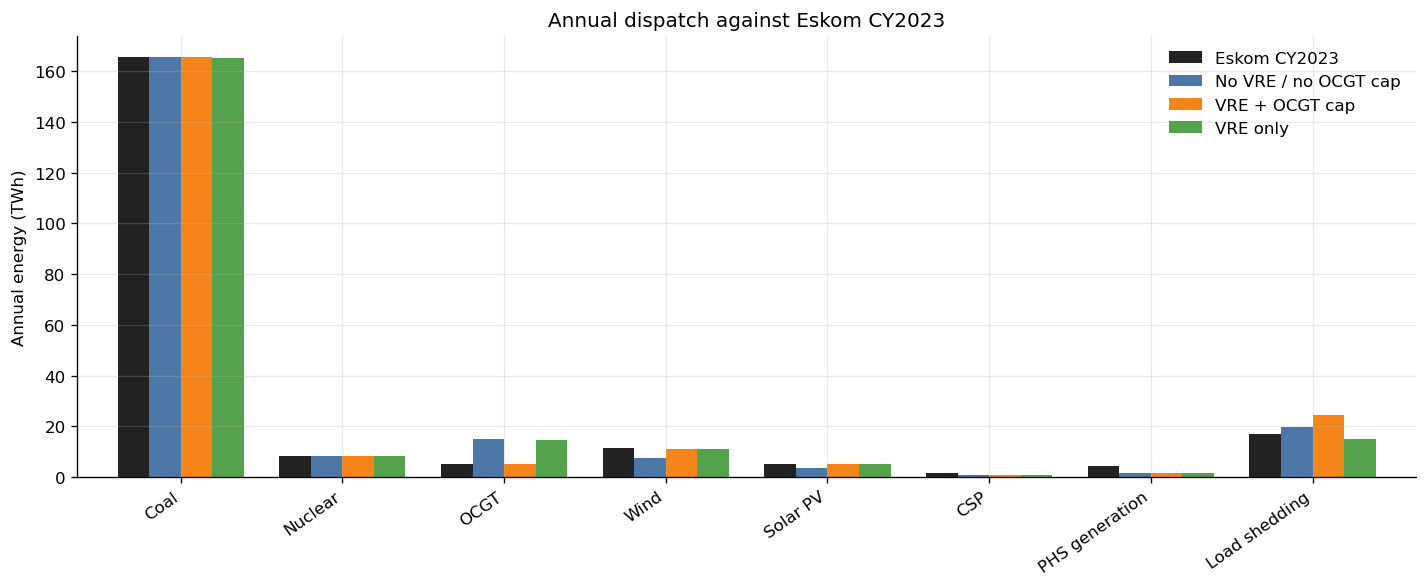

In [4]:

plot_carriers = ["coal", "nuclear", "ocgt", "wind", "solar_pv", "csp", "phs_generation", "load_shedding"]
plot_rows = []
for carrier in plot_carriers:
    plot_rows.append({"Carrier": CARRIER_LABELS[carrier], "Case": "Eskom CY2023", "TWh": eskom_annual[carrier]})
    for key, meta in SCENARIOS.items():
        plot_rows.append(
            {
                "Carrier": CARRIER_LABELS[carrier],
                "Case": meta["label"],
                "TWh": annual_twh(networks[key]["series"])[carrier],
            }
        )

plot_df = pd.DataFrame(plot_rows)
pivot = plot_df.pivot(index="Carrier", columns="Case", values="TWh").loc[[CARRIER_LABELS[c] for c in plot_carriers]]
ax = pivot.plot(
    kind="bar",
    figsize=(12, 5),
    color=[ESKOM_COLOR] + [SCENARIOS[k]["color"] for k in SCENARIOS],
    width=0.78,
)
ax.set_ylabel("Annual energy (TWh)")
ax.set_xlabel("")
ax.set_title("Annual dispatch against Eskom CY2023")
ax.legend(loc="upper right", frameon=False)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## 3. Monthly Shape

Monthly totals show whether an annual match is achieved with a plausible seasonal profile. The same physical carriers are plotted for Eskom and the three clean scenarios.

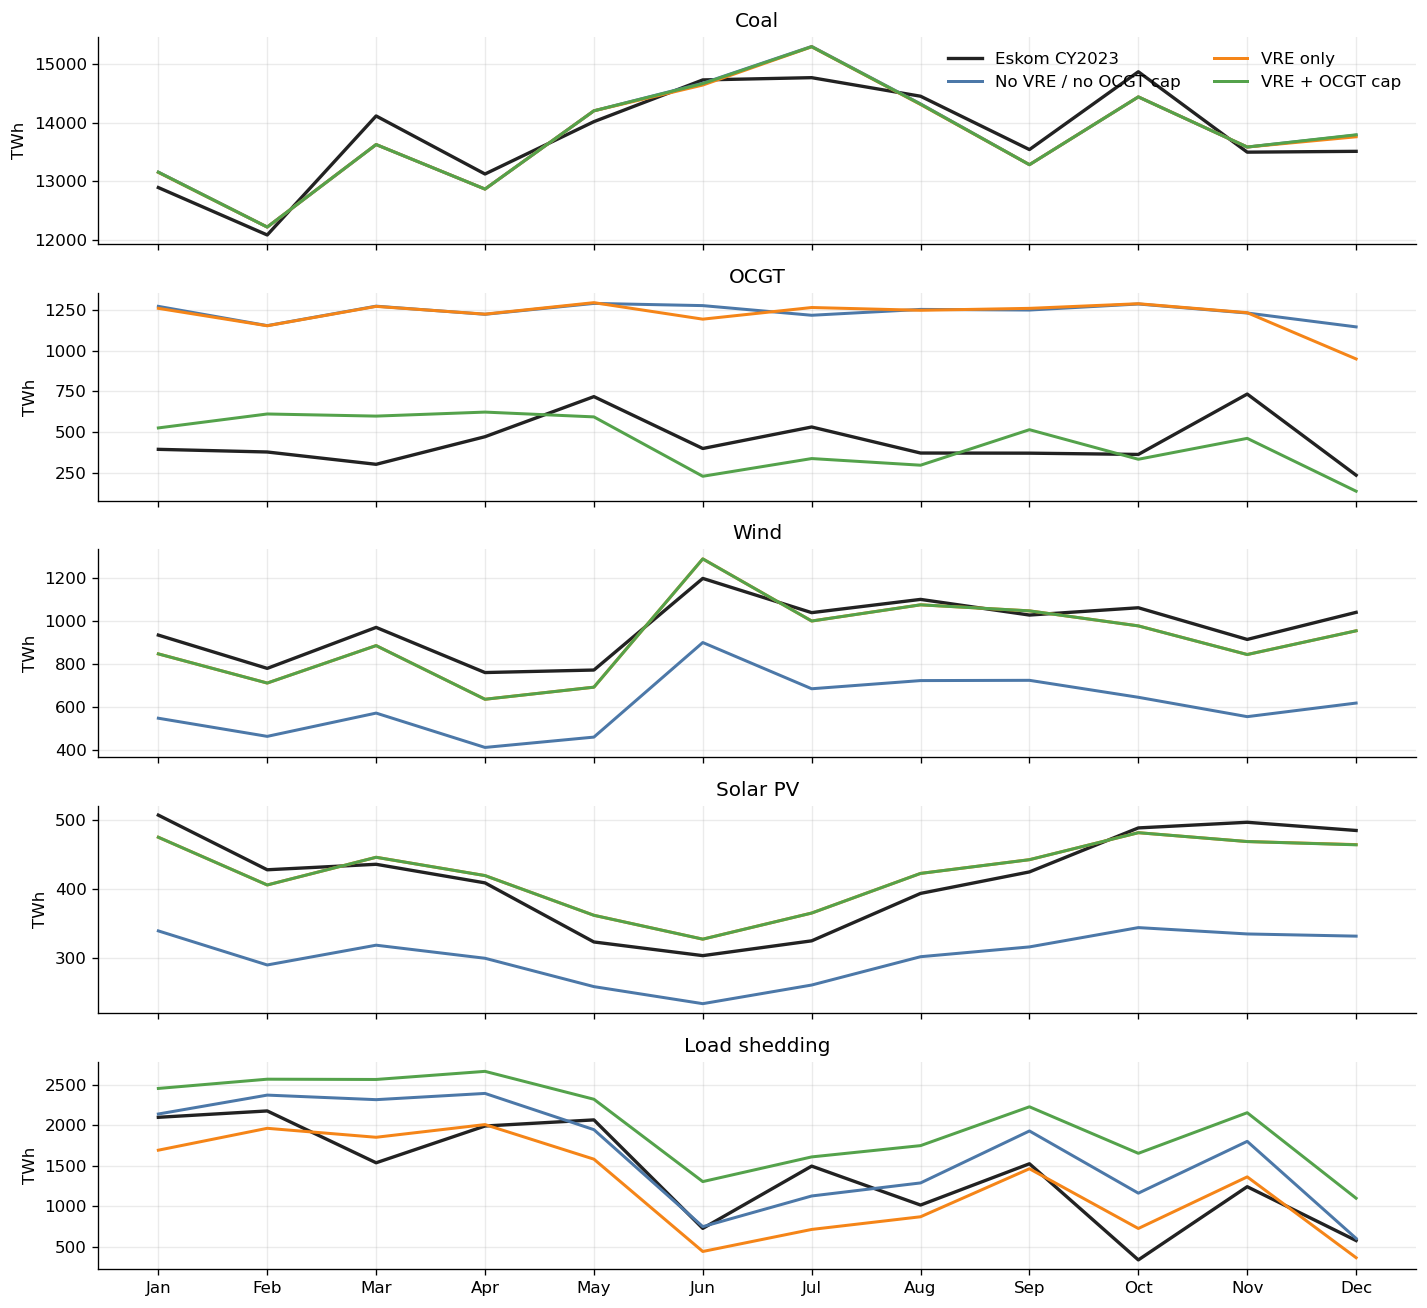

In [5]:

monthly_focus = ["coal", "ocgt", "wind", "solar_pv", "load_shedding"]
fig, axes = plt.subplots(len(monthly_focus), 1, figsize=(12, 11), sharex=True)
for ax, carrier in zip(axes, monthly_focus):
    ax.plot(monthly_twh(eskom_hourly)[carrier].values, color=ESKOM_COLOR, lw=2.0, label="Eskom CY2023")
    for key, meta in SCENARIOS.items():
        ax.plot(monthly_twh(networks[key]["series"])[carrier].values, color=meta["color"], lw=1.8, label=meta["label"])
    ax.set_ylabel("TWh")
    ax.set_title(CARRIER_LABELS[carrier])
    ax.set_xticks(range(12))
    ax.set_xticklabels(pd.date_range("2023-01-01", periods=12, freq="MS").strftime("%b"))
axes[0].legend(loc="upper right", ncol=2, frameon=False)
plt.tight_layout()
plt.show()


## 4. Hourly Fit Metrics

RMSE is reported in MW and Pearson correlation is computed from aligned hourly series. Annual gaps are model minus Eskom, so positive values mean the model dispatches more energy than observed.

In [6]:

metric_carriers = ["coal", "nuclear", "ocgt", "wind", "solar_pv", "csp", "phs_generation", "phs_pumping", "load_shedding"]
metric_rows = []
for key, meta in SCENARIOS.items():
    model = networks[key]["series"].reindex(eskom_hourly.index)
    for carrier in metric_carriers:
        metric_rows.append(
            {
                "Scenario": meta["label"],
                "Carrier": CARRIER_LABELS[carrier],
                "Annual gap TWh": annual_twh(model)[carrier] - annual_twh(eskom_hourly)[carrier],
                "Hourly RMSE MW": rmse(model[carrier], eskom_hourly[carrier]),
                "Hourly Pearson r": pearson(model[carrier], eskom_hourly[carrier]),
            }
        )

dispatch_metrics = pd.DataFrame(metric_rows)
display(dispatch_metrics.round({"Annual gap TWh": 3, "Hourly RMSE MW": 1, "Hourly Pearson r": 3}))


,Scenario,Carrier,Annual gap TWh,Hourly RMSE MW,Hourly Pearson r
0,No VRE / no OCGT cap,Coal,-0.139,1066.9,0.613
1,No VRE / no OCGT cap,Nuclear,-0.006,165.0,NaN
2,No VRE / no OCGT cap,OCGT,9.621,1443.4,0.450
3,No VRE / no OCGT cap,Wind,-4.301,589.1,0.864
4,No VRE / no OCGT cap,Solar PV,-1.389,329.5,0.927
5,No VRE / no OCGT cap,CSP,-0.570,159.5,0.456
6,No VRE / no OCGT cap,PHS generation,-2.754,658.8,0.415
7,No VRE / no OCGT cap,PHS pumping,-3.604,863.9,0.508
8,No VRE / no OCGT cap,Load shedding,3.038,1250.4,0.672
9,VRE only,Coal,-0.219,1069.0,0.611


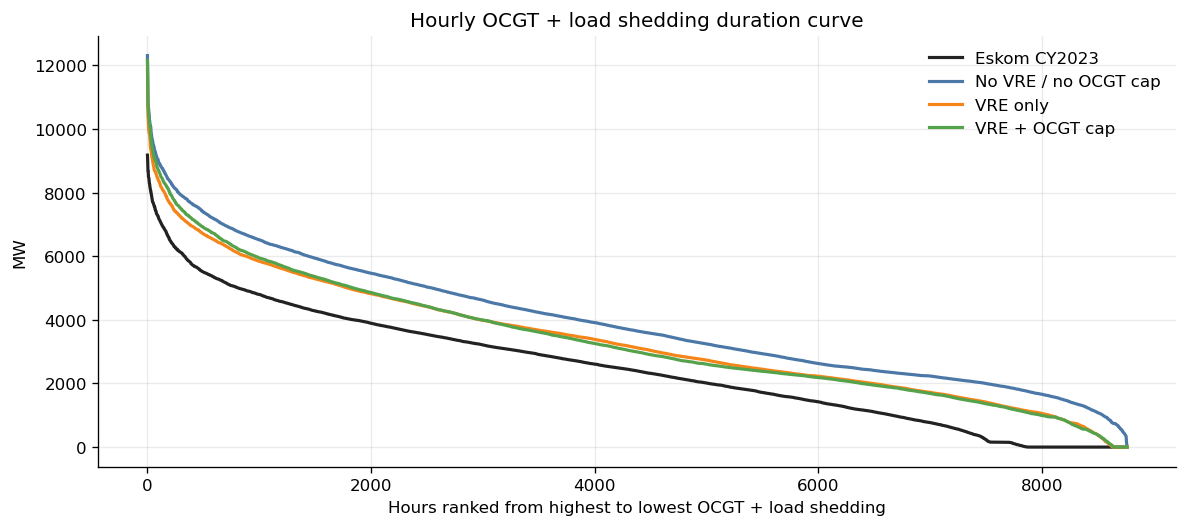

In [7]:

duration_rows = []
for case, frame, color in [("Eskom CY2023", eskom_hourly, ESKOM_COLOR)] + [
    (meta["label"], networks[key]["series"], meta["color"]) for key, meta in SCENARIOS.items()
]:
    ocgt_plus_load_shedding = frame["ocgt"] + frame["load_shedding"]
    duration_rows.append((case, np.sort(ocgt_plus_load_shedding.values)[::-1], color))

fig, ax = plt.subplots(figsize=(10, 4.5))
for case, values, color in duration_rows:
    ax.plot(values, label=case, color=color, lw=1.9)
ax.set_title("Hourly OCGT + load shedding duration curve")
ax.set_xlabel("Hours ranked from highest to lowest OCGT + load shedding")
ax.set_ylabel("MW")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## 5. Coal Availability Sanity Check

The updated coal path should keep annual coal dispatch near Eskom while applying the 48.5% target upstream in the generated availability inputs. This cell reports coal dispatch, installed coal capacity, and mean coal availability in each loaded network.

In [8]:

coal_rows = []
for key, meta in SCENARIOS.items():
    net = networks[key]["network"]
    coal_cols = net.generators.index[net.generators.carrier.eq("coal")]
    p_max = net.generators_t.p_max_pu.reindex(columns=coal_cols, fill_value=np.nan)
    coal_rows.append(
        {
            "Scenario": meta["label"],
            "Coal dispatch TWh": annual_twh(networks[key]["series"])["coal"],
            "Coal gap vs Eskom TWh": annual_twh(networks[key]["series"])["coal"] - annual_twh(eskom_hourly)["coal"],
            "Coal capacity GW": net.generators.loc[coal_cols, "p_nom"].sum() / 1e3,
            "Mean coal p_max_pu": p_max.mean().mean(),
        }
    )

coal_check = pd.DataFrame(coal_rows)
display(coal_check.round(3))


,Scenario,Coal dispatch TWh,Coal gap vs Eskom TWh,Coal capacity GW,Mean coal p_max_pu
0,No VRE / no OCGT cap,165.488,-0.139,39.099,0.485
1,VRE only,165.408,-0.219,39.099,0.485
2,VRE + OCGT cap,165.474,-0.153,39.099,0.485


## 6. Computed Summary

In [9]:

summary_rows = []
for key, meta in SCENARIOS.items():
    model_annual = annual_twh(networks[key]["series"])
    summary_rows.append(
        {
            "Scenario": meta["label"],
            "Coal TWh": model_annual["coal"],
            "Coal gap TWh": model_annual["coal"] - eskom_annual["coal"],
            "OCGT TWh": model_annual["ocgt"],
            "OCGT gap TWh": model_annual["ocgt"] - eskom_annual["ocgt"],
            "Wind+solar+CSP TWh": model_annual["wind"] + model_annual["solar_pv"] + model_annual["csp"],
            "VRE gap TWh": (
                model_annual["wind"] + model_annual["solar_pv"] + model_annual["csp"]
                - eskom_annual["wind"] - eskom_annual["solar_pv"] - eskom_annual["csp"]
            ),
            "Load shedding TWh": model_annual["load_shedding"],
            "Load shedding gap TWh": model_annual["load_shedding"] - eskom_annual["load_shedding"],
        }
    )

summary = pd.DataFrame(summary_rows)
display(summary.round(3))

best_coal = summary.iloc[(summary["Coal gap TWh"].abs()).argmin()]
cap_case = summary.loc[summary["Scenario"].eq("VRE + OCGT cap")].iloc[0]
display(
    Markdown(
        "\n".join(
            [
                f"- Coal is centered on Eskom in all three clean scenarios; the closest case is **{best_coal['Scenario']}** with a coal gap of **{best_coal['Coal gap TWh']:.3f} TWh**.",
                f"- The capped case holds OCGT to **{cap_case['OCGT TWh']:.3f} TWh**, close to Eskom's **{eskom_annual['ocgt']:.3f} TWh** reference.",
                f"- With the OCGT cap active, the remaining unmet flexibility appears as load shedding: **{cap_case['Load shedding TWh']:.3f} TWh** versus Eskom's **{eskom_annual['load_shedding']:.3f} TWh**.",
            ]
        )
    )
)


,Scenario,Coal TWh,Coal gap TWh,OCGT TWh,OCGT gap TWh,Wind+solar+CSP TWh,VRE gap TWh,Load shedding TWh,Load shedding gap TWh
0,No VRE / no OCGT cap,165.488,-0.139,14.871,9.621,11.743,-6.260,19.794,3.038
1,VRE only,165.408,-0.219,14.638,9.388,16.855,-1.149,15.007,-1.748
2,VRE + OCGT cap,165.474,-0.153,5.243,-0.007,16.854,-1.149,24.341,7.586


- Coal is centered on Eskom in all three clean scenarios; the closest case is **No VRE / no OCGT cap** with a coal gap of **-0.139 TWh**.
- The capped case holds OCGT to **5.243 TWh**, close to Eskom's **5.250 TWh** reference.
- With the OCGT cap active, the remaining unmet flexibility appears as load shedding: **24.341 TWh** versus Eskom's **16.755 TWh**.

## Method Notes

- Eskom model demand is RSA Contracted Demand - International Imports + International Exports - Other RE - unattributed dispatchable residual.
- Eskom OCGT is the sum of Eskom OCGT generation, dispatchable IPP OCGT, and Eskom gas generation.
- Eskom load shedding is MLR + ILS + IOS, which is the observed curtailment proxy used throughout this validation layer.
- Pumped hydro is reported gross: generation and pumping are separate positive quantities.
- The three model cases are all updated clean Module 14c network outputs. No earlier calibration network is used as a comparison case in this notebook.